**ASSIGNMENT 5 - Perceptron vs Multilayer Perceptron with Hyperparameter Tuning**

NAME : MADUSSREE RAVI

CSE B

DATE : 06-02-2026

3122235001074

**IMPORTS**

In [1]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

**LOADING THE DATASET**

In [3]:
df=pd.read_csv("english.csv")

In [4]:
df.shape

(3410, 2)

In [5]:
df.tail()

,image,label
3405,Img/img062-051.png,z
3406,Img/img062-052.png,z
3407,Img/img062-053.png,z
3408,Img/img062-054.png,z
3409,Img/img062-055.png,z


In [6]:
df["label"].value_counts()

label
0    55
k    55
X    55
Y    55
Z    55
     ..
P    55
Q    55
R    55
S    55
z    55
Name: count, Length: 62, dtype: int64

In [7]:
lb = LabelEncoder()
df["label"] = lb.fit_transform(df["label"])
print(df["label"])

0        0
1        0
2        0
3        0
4        0
        ..
3405    61
3406    61
3407    61
3408    61
3409    61
Name: label, Length: 3410, dtype: int64


In [8]:
images=[]
labels=[]

for index,row in df.iterrows():
    img_path=row['image']
    label=row['label']

    img=cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img=cv2.resize(img,(40,30)) #Reszing into square image


    img=img.flatten()
    img=img/255.0
    images.append(img)
    labels.append(label)

X=np.array(images)
y=np.array(labels)
    

In [9]:
print(X.shape)
print(y.shape)

(3410, 1200)
(3410,)


In [10]:
print(len(X))
print(len(y))

3410
3410


In [11]:
print(X[0])

[1. 1. 1. ... 1. 1. 1.]


**LABEL ENCODING**

Single Layer Perceptron

In [12]:
lb = LabelEncoder()
y_encoded = lb.fit_transform(y)
print(y_encoded)

[ 0  0  0 ... 61 61 61]


**Train Test Split**

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2, shuffle=True)

In [14]:
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)

(2728, 1200)
(2728,)
(682,)
(682, 1200)


**MODEL A : Single Layer Perceptron**

STEP FUNCTION DEFINITION

In [15]:
def step_function(x):
    return np.where(x>=0,1,0)

In [16]:
class Perceptron:
    def __init__(self,learning_rate=0.01,epochs=10):
        self.lr=learning_rate
        self.epochs=epochs

    def fit(self,X,y):
        self.weights=np.zeros(X.shape[1])
        self.bias=0
        for epoch in range(self.epochs):

            for xi, yi in zip(X, y):
    
                linear_output = np.dot(xi, self.weights) + self.bias
                y_pred = step_function(linear_output)
    
                update = self.lr * (yi - y_pred)
    
                self.weights += update * xi
                self.bias += update

    def predict(self,X):
        predictions=[]
        for i in range(len(X)):
            linear_output=np.dot(X[i],self.weights) + self.bias
            y_pred = step_function(linear_output)
            predictions.append(y_pred)
    
        return np.array(predictions)



**ONE-VS-REST TRAINING**

In [17]:
num_classes = len(np.unique(y_train))
perceptrons = []

for class_value in range(num_classes):
    
    print("Training for class:", class_value)
    
    y_binary = np.where(y_train == class_value, 1, 0)
    
    p = Perceptron(learning_rate=0.01, epochs=5)
    p.fit(X_train, y_binary)
    
    perceptrons.append(p)


Training for class: 0
Training for class: 1
Training for class: 2
Training for class: 3
Training for class: 4
Training for class: 5
Training for class: 6
Training for class: 7
Training for class: 8
Training for class: 9
Training for class: 10
Training for class: 11
Training for class: 12
Training for class: 13
Training for class: 14
Training for class: 15
Training for class: 16
Training for class: 17
Training for class: 18
Training for class: 19
Training for class: 20
Training for class: 21
Training for class: 22
Training for class: 23
Training for class: 24
Training for class: 25
Training for class: 26
Training for class: 27
Training for class: 28
Training for class: 29
Training for class: 30
Training for class: 31
Training for class: 32
Training for class: 33
Training for class: 34
Training for class: 35
Training for class: 36
Training for class: 37
Training for class: 38
Training for class: 39
Training for class: 40
Training for class: 41
Training for class: 42
Training for class: 4

**MULTI CLASS PERCEPTRON**

In [18]:
print("X_test shape:", X_test.shape)

X_test shape: (682, 1200)


In [19]:
X_test = X_test.reshape(X_test.shape[0], -1)

In [20]:
print("X_test shape:", X_test.shape)

X_test shape: (682, 1200)


In [21]:
def ovr_predict(X):
    
    scores = []
    
    for p in perceptrons:
        score = np.dot(X, p.weights) + p.bias
        scores.append(score)
    
    scores = np.array(scores)   # shape → (num_classes, num_samples)
    
    predictions = np.argmax(scores, axis=0)
    
    return predictions

In [22]:
print(X_test.shape)       # should be (samples, 784)
print(perceptrons[0].weights.shape)   # should be (784,)

(682, 1200)
(1200,)


In [ ]:
y_pred_pla = ovr_predict(X_test)

print("PLA Accuracy:", accuracy_score(y_test, y_pred_pla))

**MODEL B : MULTILAYER PERCEPTRON**

In [23]:
from sklearn.neural_network import MLPClassifier

**MODEL 1**

In [24]:
mlp1 = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='sgd',
    alpha=0.01,
    batch_size=32,
    max_iter=100,
    random_state=2
)

mlp1.fit(X_train, y_train)

y_pred1 = mlp1.predict(X_test)

print("Model 1 Accuracy:", accuracy_score(y_test, y_pred1))

Model 1 Accuracy: 0.3680351906158358


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [25]:
accuracy = accuracy_score(y_test, y_pred1)
print("Accuracy:", accuracy)

Accuracy: 0.3680351906158358


**MODEL 2**

In [26]:
mlp2 = MLPClassifier(
    hidden_layer_sizes=(256,128),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=64,
    max_iter=100,
    random_state=2
)

mlp2.fit(X_train, y_train)

y_pred2 = mlp2.predict(X_test)

print("Model 2 Accuracy:", accuracy_score(y_test, y_pred2))

Model 2 Accuracy: 0.41348973607038125


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


**MODEL 3**

In [27]:
mlp3 = MLPClassifier(
    hidden_layer_sizes=(512,256,128),
    activation='tanh',
    solver='adam',
    alpha=0.0005,
    batch_size=64,
    max_iter=100,
    random_state=42
)

mlp3.fit(X_train, y_train)

y_pred3 = mlp3.predict(X_test)

print("Model 3 Accuracy:", accuracy_score(y_test, y_pred3))

Model 3 Accuracy: 0.17302052785923755


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


**CLASSIFICATION REPORT**

*Model 2 has the best accuracy - implementing the ROC curve and other metrics for the same*

In [29]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.19      0.75      0.30         8
           1       0.62      0.40      0.48        20
           2       0.44      0.27      0.33        15
           3       0.50      0.22      0.31         9
           4       0.38      0.36      0.37        14
           5       0.33      0.22      0.27         9
           6       0.64      0.70      0.67        10
           7       0.00      0.00      0.00         0
           8       0.75      0.55      0.63        11
           9       0.62      0.38      0.48        13
          10       0.60      0.35      0.44        17
          11       0.33      0.50      0.40        10
          12       1.00      0.67      0.80         6
          13       0.42      0.56      0.48         9
          14       0.50      0.36      0.42        11
          15       0.50      0.67      0.57         6
          16       0.38      0.55      0.44        11
          17       0.53    

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


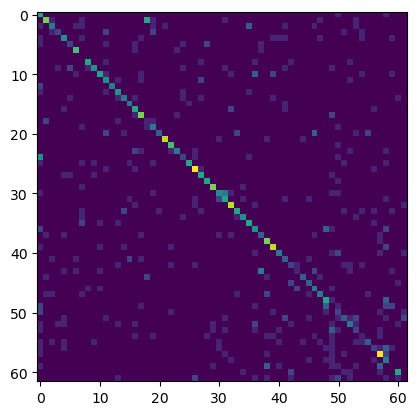

In [30]:
cm = confusion_matrix(y_test, y_pred2)
plt.imshow(cm)

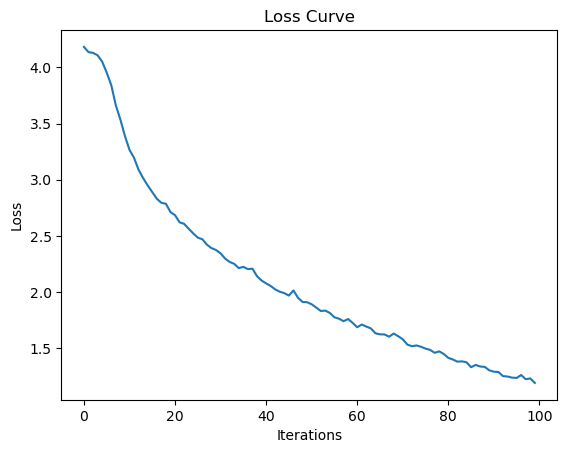

In [31]:
plt.plot(mlp2.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

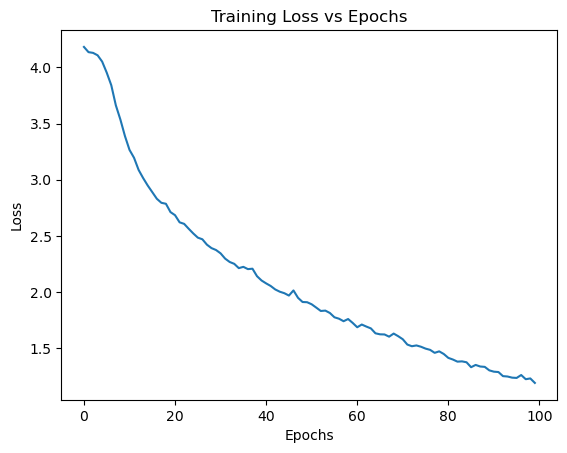

In [33]:
plt.plot(mlp2.loss_curve_)
plt.title("Training Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [34]:
from sklearn.preprocessing import label_binarize

classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

In [36]:
from sklearn.metrics import roc_curve, auc

y_prob = mlp2.predict_proba(X_test)
fpr = dict()
tpr = dict()
roc_auc = dict()

n_classes = y_test_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


MICRO AVERAGE ROC

In [37]:
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(), y_prob.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

MACRO AVERAGE ROC

In [38]:
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

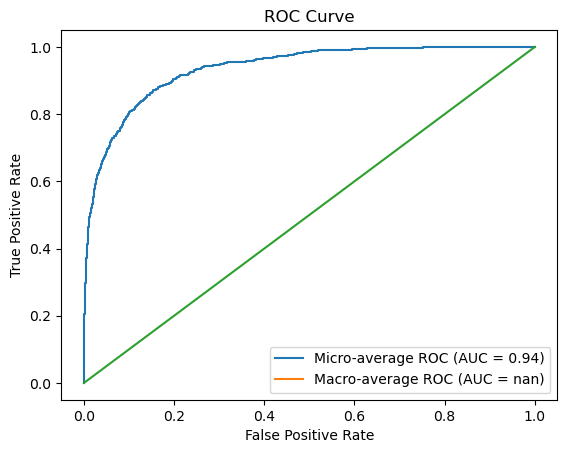

In [39]:
plt.figure()

plt.plot(fpr["micro"], tpr["micro"],
         label="Micro-average ROC (AUC = %0.2f)" % roc_auc["micro"])

plt.plot(fpr["macro"], tpr["macro"],
         label="Macro-average ROC (AUC = %0.2f)" % roc_auc["macro"])

plt.plot([0, 1], [0, 1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**LEARNING OUTCOMES**

Through this assignment, I have learnt and understood how single layer and multi-layer perceptrons work and how hyperparameter tuning makes a difference to the result.